1. Program Tanpa Lock

In [2]:
import threading

saldo = 1_000_000

def transaksi():
    global saldo

    for _ in range(10_000):
        saldo -= 1
        saldo += 1

threads = []

for i in range(10):
    thread = threading.Thread(target=transaksi)
    threads.append(thread)
    thread.start()

for thread in threads:
    thread.join()

print("Saldo awal :", 1_000_000)
print("Saldo akhir:", saldo)

Saldo awal : 1000000
Saldo akhir: 1000000


Program dengan threading.Lock()

In [3]:
import threading

saldo = 1_000_000
lock = threading.Lock()

def transaksi():
    global saldo

    for _ in range(10_000):
        with lock:
            saldo -= 1
            saldo += 1

threads = []

for i in range(10):
    thread = threading.Thread(target=transaksi)
    threads.append(thread)
    thread.start()

for thread in threads:
    thread.join()

print("Saldo awal :", 1_000_000)
print("Saldo akhir:", saldo)

Saldo awal : 1000000
Saldo akhir: 1000000


Perbandingan

Pada program tanpa Lock, 10 thread mengakses variabel saldo secara bersamaan sehingga terdapat kemungkinan terjadinya race condition. Pada hasil pengujian, saldo akhir tetap Rp1.000.000.

Pada program dengan threading.Lock(), akses terhadap variabel saldo diberi pengunci menggunakan Lock. Dengan demikian, hanya satu thread yang dapat melakukan operasi pada saldo pada satu waktu. Hasil akhirnya juga tetap Rp1.000.000.

Perbedaannya adalah program tanpa Lock tidak memberikan pengamanan terhadap akses bersama pada variabel saldo, sedangkan program dengan Lock memberikan pengamanan sehingga akses antar-thread dapat dikendalikan.

2. Producer-Consumer dengan Banyak Consumer

In [4]:
import threading
import queue
import time

q = queue.Queue()

def producer():
    for i in range(10):
        item = f"Data-{i}"
        q.put(item)
        print(f"Producer menghasilkan: {item}")
        time.sleep(0.1)

    for _ in range(3):
        q.put(None)

    print("Producer selesai")


def consumer(nama):
    while True:
        item = q.get()

        if item is None:
            print(f"{nama} berhenti")
            q.task_done()
            break

        print(f"{nama} memproses: {item}")
        time.sleep(0.2)

        q.task_done()


producer_thread = threading.Thread(target=producer)

consumer_threads = []

for i in range(3):
    thread = threading.Thread(
        target=consumer,
        args=(f"Consumer-{i+1}",)
    )
    consumer_threads.append(thread)


producer_thread.start()

for thread in consumer_threads:
    thread.start()


producer_thread.join()

for thread in consumer_threads:
    thread.join()

print("Semua thread selesai")

Producer menghasilkan: Data-0
Consumer-1 memproses: Data-0
Producer menghasilkan: Data-1
Consumer-2 memproses: Data-1
Producer menghasilkan: Data-2Consumer-3 memproses: Data-2

Producer menghasilkan: Data-3
Consumer-1 memproses: Data-3
Producer menghasilkan: Data-4Consumer-2 memproses: Data-4

Producer menghasilkan: Data-5
Consumer-3 memproses: Data-5
Producer menghasilkan: Data-6Consumer-1 memproses: Data-6

Producer menghasilkan: Data-7
Consumer-2 memproses: Data-7
Producer menghasilkan: Data-8
Consumer-3 memproses: Data-8
Producer menghasilkan: Data-9Consumer-1 memproses: Data-9

Producer selesai
Consumer-2 berhenti
Consumer-3 berhenti
Consumer-1 berhenti
Semua thread selesai


Analisis

Program ini menggunakan queue.Queue() untuk menghubungkan satu producer dengan tiga consumer. Producer bertugas menghasilkan 10 data, yaitu Data-0 sampai Data-9, kemudian memasukkannya ke dalam queue menggunakan q.put().

Tiga consumer mengambil data dari queue menggunakan q.get(). Setiap data yang diambil akan diproses oleh salah satu consumer. Karena terdapat tiga consumer yang berjalan secara bersamaan, pembagian data dapat berbeda pada setiap eksekusi program.

Setelah producer selesai menghasilkan seluruh data, producer memasukkan None sebanyak tiga kali ke dalam queue. Ketiga None tersebut digunakan sebagai sinyal berhenti, masing-masing untuk satu consumer.

Ketika consumer menerima None, consumer menampilkan pesan berhenti dan keluar dari perulangan. Setelah seluruh thread selesai, program menampilkan Semua thread selesai.

Kesimpulan

Program berhasil menerapkan 1 producer dan 3 consumer menggunakan queue.Queue(). Producer menghasilkan data dan memasukkannya ke dalam queue, sedangkan tiga consumer mengambil dan memproses data tersebut. Sinyal None diberikan sebanyak tiga kali agar seluruh consumer dapat berhenti setelah producer selesai.

3. Eksperimen ProcessPoolExecutor

max_workers = 2
Waktu eksekusi = 1.9693 detik
----------------------------------------
max_workers = 4
Waktu eksekusi = 1.0406 detik
----------------------------------------
max_workers = 8
Waktu eksekusi = 0.7313 detik
----------------------------------------
max_workers = 16
Waktu eksekusi = 0.7467 detik
----------------------------------------

Perbandingan waktu eksekusi:
max_workers = 2: 1.9693 detik
max_workers = 4: 1.0406 detik
max_workers = 8: 0.7313 detik
max_workers = 16: 0.7467 detik


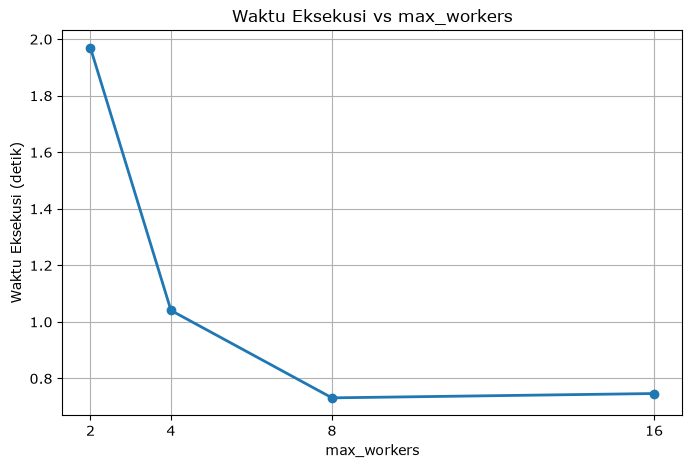

In [4]:
import time
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor
from worker import proses_file

jumlah_file = 50

workers_list = [2, 4, 8, 16]

hasil = {}

for max_workers in workers_list:
    start_time = time.perf_counter()

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        hasil_proses = list(
            executor.map(
                proses_file,
                range(1, jumlah_file + 1)
            )
        )

    end_time = time.perf_counter()

    waktu = end_time - start_time
    hasil[max_workers] = waktu

    print(f"max_workers = {max_workers}")
    print(f"Waktu eksekusi = {waktu:.4f} detik")
    print("-" * 40)

print("\nPerbandingan waktu eksekusi:")

for workers, waktu in hasil.items():
    print(f"max_workers = {workers}: {waktu:.4f} detik")

plt.figure(figsize=(8, 5))

plt.plot(
    list(hasil.keys()),
    list(hasil.values()),
    marker='o',
    linewidth=2
)

plt.xlabel("max_workers")
plt.ylabel("Waktu Eksekusi (detik)")
plt.title("Waktu Eksekusi vs max_workers")
plt.xticks(workers_list)
plt.grid(True)

plt.show()

Analisis

Berdasarkan hasil eksperimen dengan jumlah file sebanyak 50, diperoleh waktu eksekusi sebesar 1,9693 detik pada max_workers = 2, 1,0406 detik pada max_workers = 4, 0,7313 detik pada max_workers = 8, dan 0,7467 detik pada max_workers = 16. Dari hasil tersebut, peningkatan max_workers dari 2 menjadi 4 dan dari 4 menjadi 8 dapat mempercepat proses karena pekerjaan dapat dijalankan secara paralel. Namun, ketika max_workers ditingkatkan dari 8 menjadi 16, waktu eksekusi justru sedikit meningkat dari 0,7313 detik menjadi 0,7467 detik.

Hal ini menunjukkan bahwa penambahan max_workers tidak selalu membuat proses semakin cepat. Pada jumlah worker yang terlalu banyak, proses harus berbagi sumber daya CPU dan terdapat overhead dalam pengaturan serta pengelolaan proses. Berdasarkan hasil percobaan, titik jenuh mulai terlihat pada max_workers = 8 karena penambahan worker menjadi 16 tidak lagi meningkatkan kecepatan, bahkan menghasilkan waktu eksekusi yang sedikit lebih lama. Jadi, semakin banyak max_workers tidak selalu menghasilkan waktu eksekusi yang lebih cepat.

4. Refleksi Singkat

Contoh kasus nyata di mana threading membantu adalah pada aplikasi pengunduhan beberapa file dari internet. Beberapa file dapat diunduh secara bersamaan menggunakan beberapa thread. Hal ini membantu karena proses pengunduhan banyak menunggu respons jaringan, sehingga thread lain dapat tetap menjalankan tugas tanpa harus menunggu satu unduhan selesai.

Contoh kasus nyata di mana multiprocessing membantu adalah pengolahan banyak gambar, seperti mengubah ukuran atau memberikan filter pada ratusan gambar. Beberapa proses dapat mengolah gambar yang berbeda secara bersamaan sehingga pekerjaan yang membutuhkan banyak pemrosesan CPU dapat diselesaikan lebih cepat.

Dari kedua contoh tersebut, threading cocok untuk pekerjaan yang banyak menunggu proses I/O, sedangkan multiprocessing cocok untuk pekerjaan yang membutuhkan pemrosesan CPU.